# 01 — CVD for BTC (cumulative volume delta)

**Goal:** build the first derived order-flow series — **CVD** — from the trade
tape, and *look* at it against price. Nothing predictive yet: this step is
"does CVD compute cleanly and does it move with price at all?".

Recap of what CVD is (from our discussion):

- Each trade has a `side` = **aggressor** (`buy` = a market buy lifted the ask,
  `sell` = a market sell hit the bid).
- **Signed volume** of a trade = `+amount` if buy, `−amount` if sell (amount in
  BTC).
- **CVD** = running cumulative sum of signed volume. It's a **flow** measure of
  *taker aggression* — "net BTC that market orders lifted vs hit, so far".
- It is **backward-looking** by construction (a sum over past trades) — no
  lookahead as long as we read it as-of each trade's own time.

What we do NOT claim here: that CVD *predicts* price. That's a later step
(lead/lag). Here we only build it and eyeball contemporaneous co-movement.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SESS = "2026-07-09T08-03-30Z"
SYM  = "BTCUSDT"

tr = load(SESS, "trades",    SYM, with_datetime=True)
ob = load(SESS, "orderbook", SYM, with_datetime=True)
print(f"{len(tr):,} trades, {len(ob):,} book snapshots")
print("trade side values:", tr['side'].value_counts().to_dict())

1,325,127 trades, 185,523 book snapshots
trade side values: {'sell': 679365, 'buy': 645762}


## 1. Signed volume + sanity

Before summing, sanity-check the raw ingredients: how much volume was
aggressive-buy vs aggressive-sell over the whole session, and the net. If the
tape is roughly balanced (as a calm session should be) the net will be a small
fraction of gross — that's the honest baseline.

In [2]:
sign = np.where(tr['side'] == 'buy', 1.0, np.where(tr['side'] == 'sell', -1.0, 0.0))
tr = tr.assign(signed=sign * tr['amount'])

buy_vol  = tr.loc[tr['side'] == 'buy',  'amount'].sum()
sell_vol = tr.loc[tr['side'] == 'sell', 'amount'].sum()
gross    = buy_vol + sell_vol
net      = buy_vol - sell_vol
print(f"buy  (taker) volume : {buy_vol:12,.1f} BTC")
print(f"sell (taker) volume : {sell_vol:12,.1f} BTC")
print(f"gross               : {gross:12,.1f} BTC")
print(f"net (buy-sell)      : {net:12,.1f} BTC   ({100*net/gross:+.1f}% of gross)")
print(f"buy share of gross  : {100*buy_vol/gross:.1f}%")

buy  (taker) volume :     20,560.9 BTC
sell (taker) volume :     19,903.3 BTC
gross               :     40,464.2 BTC
net (buy-sell)      :        657.6 BTC   (+1.6% of gross)
buy share of gross  : 50.8%


## 2. CVD = cumulative signed volume

The running sum. Its **end value equals the net above** (by definition — a
cumulative sum ends at the total). What's interesting is the *path*: where it
climbs (buyers pressing) vs falls (sellers pressing).

In [3]:
tr = tr.assign(cvd=tr['signed'].cumsum())
print(f"CVD start : {tr['cvd'].iloc[0]:+.3f} BTC")
print(f"CVD end   : {tr['cvd'].iloc[-1]:+,.1f} BTC   (== net above, by construction)")
print(f"CVD min   : {tr['cvd'].min():+,.1f} BTC")
print(f"CVD max   : {tr['cvd'].max():+,.1f} BTC")

CVD start : +0.010 BTC
CVD end   : +657.6 BTC   (== net above, by construction)
CVD min   : -755.2 BTC
CVD max   : +899.3 BTC


## 3. Look: mid price vs CVD

Two panels sharing the time axis:

- **top** — BTC mid price (what actually happened to price).
- **bottom** — CVD (net taker aggression, in BTC).

If aggressive buying pushes price, the two lines should broadly rise and fall
together. We resample both to a 10-second grid just so the lines are legible
(1.3M raw points is a smear). Reading CVD: an **up-slope = buyers dominating**
the tape, **down-slope = sellers dominating**; the *level* is cumulative history.

[saved] microstructure\initial\_out\01_btc_cvd_mid.png


WindowsPath('C:/projects/researchlab/microstructure/initial/_out/01_btc_cvd_mid.png')

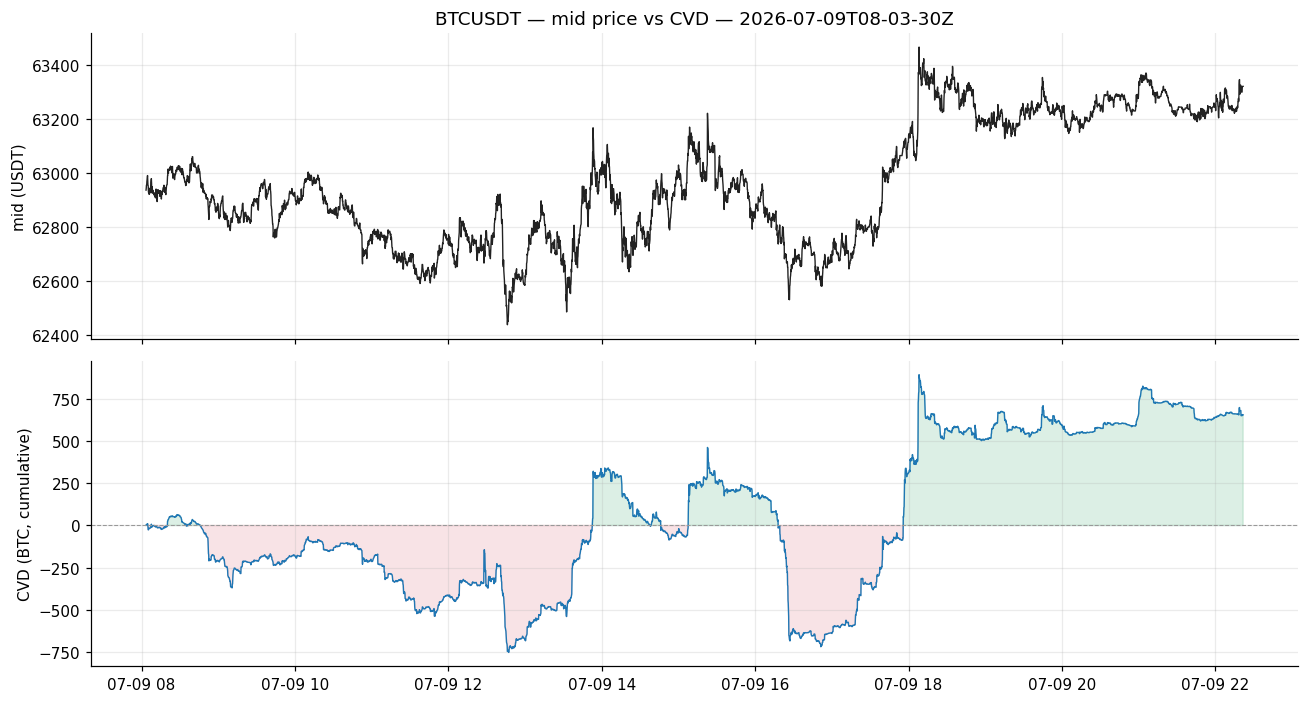

In [4]:
GRID = "10s"
m_px  = mid(ob).resample(GRID).last().ffill()
cvd_g = tr['cvd'].resample(GRID).last().ffill()
# align to common index
idx = m_px.index.intersection(cvd_g.index)
m_px, cvd_g = m_px.loc[idx], cvd_g.loc[idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1]})
ax1.plot(m_px.index, m_px.values, lw=0.9, color="#222")
ax1.set_ylabel("mid (USDT)")
ax1.set_title(f"{SYM} — mid price vs CVD — {SESS}")

ax2.plot(cvd_g.index, cvd_g.values, lw=0.9, color="#1f77b4")
ax2.axhline(0, color="#999", lw=0.7, ls="--")
ax2.fill_between(cvd_g.index, 0, cvd_g.values,
                 where=cvd_g.values >= 0, color="#159a52", alpha=0.15)
ax2.fill_between(cvd_g.index, 0, cvd_g.values,
                 where=cvd_g.values < 0, color="#d1495b", alpha=0.15)
ax2.set_ylabel("CVD (BTC, cumulative)")
show("01_btc_cvd_mid")

## 4. A first (contemporaneous, not predictive) number

Do CVD moves and price moves line up *at the same time*? We take 10s bins,
compute the **change** in each within the bin (ΔCVD = net taker flow that bin,
Δmid = price move that bin), and correlate them. This is a sanity check that
CVD relates to price at all — it is **contemporaneous** (same bin), so it says
nothing about *leading*. A positive correlation just means "bins with more net
buying tended to have price up in the same bin", which we'd expect if taker
flow moves price.

In [5]:
d_cvd = cvd_g.diff()
d_mid = m_px.diff()
d = pd.concat([d_cvd.rename("dCVD"), d_mid.rename("dMID")], axis=1).dropna()
corr = d["dCVD"].corr(d["dMID"])
print(f"bins: {len(d):,} @ {GRID}")
print(f"contemporaneous corr( dCVD , dMID ) = {corr:+.3f}")
print(f"(sign check) bins where dCVD>0: mean dMID = {d.loc[d.dCVD>0,'dMID'].mean():+.3f} USDT")
print(f"(sign check) bins where dCVD<0: mean dMID = {d.loc[d.dCVD<0,'dMID'].mean():+.3f} USDT")

bins: 5,149 @ 10s
contemporaneous corr( dCVD , dMID ) = +0.463
(sign check) bins where dCVD>0: mean dMID = +6.709 USDT
(sign check) bins where dCVD<0: mean dMID = -6.188 USDT


## 5. Where we are

**Verdict (fill after run):** CVD computes cleanly; its end value matches the
net taker volume by construction; the path tracks price direction with a
positive contemporaneous correlation.

**How to read the chart:** top = price, bottom = cumulative net taker flow.
Green shading = net buyers have dominated since the start, red = net sellers.
Slope, not level, is the instantaneous pressure.

**Honest caveats:** contemporaneous only (no lead/lag yet); single session /
single symbol; taker `side` is Bybit's aggressor tag (we trust it); no cost
model. Correlation ≠ tradeable — mechanically, flow and price moving together
is partly a tautology (market orders move price by definition).

**Next step (nb 02):** the real question — does CVD **lead** price, or just move
with it? Lead/lag: correlate ΔCVD at time *t* with Δmid at *t+k* for k = a few
seconds to a minute, vs a shuffled baseline. If the lead correlation is ~0
(likely), CVD is descriptive not predictive — and we pivot to the CVD↔OI bridge.